## Apply RNN : Many-to-One

- 7일까지의 데이터를 가지고 8일차의 종가 데이터를 예측하는 모델을 만들어 볼 예정.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 정규화
def MinMaxScaler(data):
    numerator = data - np.min(data, axis=0)
    denominator = np.max(data, axis=0) - np.min(data, axis=0)
    return numerator / (denominator + 1e-7)

In [4]:
data = np.loadtxt('./data/data-02-stock_daily.csv', delimiter=',')
print(data.shape, '\n', data)

(732, 5) 
 [[8.28659973e+02 8.33450012e+02 8.28349976e+02 1.24770000e+06
  8.31659973e+02]
 [8.23020020e+02 8.28070007e+02 8.21655029e+02 1.59780000e+06
  8.28070007e+02]
 [8.19929993e+02 8.24400024e+02 8.18979980e+02 1.28170000e+06
  8.24159973e+02]
 ...
 [5.66892592e+02 5.67002574e+02 5.56932537e+02 1.08000000e+04
  5.56972503e+02]
 [5.61202549e+02 5.66432590e+02 5.58672539e+02 4.12000000e+04
  5.59992565e+02]
 [5.68002570e+02 5.68002570e+02 5.52922516e+02 1.31000000e+04
  5.58462551e+02]]


In [5]:
# 날짜순으로 만들기 위해 뒤집어 줌(과거 -> 현재 순)

data = data[::-1] # 콜론을 기준으로 왼쪽은 시작, -1은 역순으로 읽어옴(과거 -> 현재 순)
data

array([[5.68002570e+02, 5.68002570e+02, 5.52922516e+02, 1.31000000e+04,
        5.58462551e+02],
       [5.61202549e+02, 5.66432590e+02, 5.58672539e+02, 4.12000000e+04,
        5.59992565e+02],
       [5.66892592e+02, 5.67002574e+02, 5.56932537e+02, 1.08000000e+04,
        5.56972503e+02],
       ...,
       [8.19929993e+02, 8.24400024e+02, 8.18979980e+02, 1.28170000e+06,
        8.24159973e+02],
       [8.23020020e+02, 8.28070007e+02, 8.21655029e+02, 1.59780000e+06,
        8.28070007e+02],
       [8.28659973e+02, 8.33450012e+02, 8.28349976e+02, 1.24770000e+06,
        8.31659973e+02]], shape=(732, 5))

In [ ]:
# 7일까지의 데이터를 가지고 8일차의 종가 데이터를 예측하는 모델
# 이전 7일치 데이터 : 학습 데이터
timesteps = seq_length = 7
input_features = 5  # Open,	High, Low, Volume, Close
output_dim = 1  # 8일차 데이터 : 정답 데이터 

train_size = int(len(data) * 0.8)

train_set = data[0:train_size]
test_set = data[train_size - seq_length:]  # 태스트 데이터 154개(8:2의 비율)

In [7]:
print(train_size, train_set.shape, test_set.shape)

585 (585, 5) (154, 5)


In [8]:
# 데이터의 단위가 상이함 -> 정규화

train_set = MinMaxScaler(train_set)
test_set = MinMaxScaler(test_set)

In [10]:
# (585, 5) (154, 5)

def build_dataset(time_series, seq_length):
    dataX = []
    dataY = []
    
    for i in range(0, len(time_series) - seq_length): # 1일씩 이동해 나가면서 최대 7개까지 남았을때 까지 학습
        x = time_series[i:i+seq_length, :]  # 7일간의 입력 데이터(0~7), 5개 컬럼
        y = time_series[i+seq_length, [-1]] # 8일차 종가 데이터 (7~8일차)
        print(x, ' => ', y)
        dataX.append(x)
        dataY.append(y)
        
    return np.array(dataX), np.array(dataY)

In [11]:
trainX, trainY = build_dataset(train_set, seq_length) # train_set 훈련용 데이터, 정답 데이터 추출, seq_length 7을 입력으로 전달

[[2.53065030e-01 2.45070970e-01 2.33983036e-01 4.66075110e-04
  2.32039560e-01]
 [2.29604366e-01 2.39728936e-01 2.54567513e-01 2.98467330e-03
  2.37426028e-01]
 [2.49235510e-01 2.41668371e-01 2.48338489e-01 2.59926504e-04
  2.26793794e-01]
 [2.21013495e-01 2.46602231e-01 2.54710584e-01 0.00000000e+00
  2.62668239e-01]
 [3.63433786e-01 3.70389871e-01 2.67168847e-01 1.24764722e-02
  2.62105010e-01]
 [2.59447633e-01 3.10673724e-01 2.74113889e-01 4.56323384e-01
  2.71751265e-01]
 [2.76008150e-01 2.78314566e-01 1.98470380e-01 5.70171193e-01
  1.78104644e-01]]  =>  [0.16053716]
[[2.29604366e-01 2.39728936e-01 2.54567513e-01 2.98467330e-03
  2.37426028e-01]
 [2.49235510e-01 2.41668371e-01 2.48338489e-01 2.59926504e-04
  2.26793794e-01]
 [2.21013495e-01 2.46602231e-01 2.54710584e-01 0.00000000e+00
  2.62668239e-01]
 [3.63433786e-01 3.70389871e-01 2.67168847e-01 1.24764722e-02
  2.62105010e-01]
 [2.59447633e-01 3.10673724e-01 2.74113889e-01 4.56323384e-01
  2.71751265e-01]
 [2.76008150e-01 2.78

In [12]:
testX, testY = build_dataset(test_set, seq_length)

[[0.01755122 0.01494887 0.         0.08423004 0.        ]
 [0.         0.         0.01058343 0.08767242 0.03344875]
 [0.03570476 0.02948028 0.01977594 0.16689536 0.0241806 ]
 [0.00972215 0.11625175 0.038924   0.17079512 0.14154561]
 [0.07149617 0.12343385 0.10896883 0.15442575 0.16833804]
 [0.13550721 0.16636032 0.18161435 0.16939891 0.20397693]
 [0.16157594 0.16268567 0.17023335 0.10599167 0.18240816]]  =>  [0.21703605]
[[0.         0.         0.01058343 0.08767242 0.03344875]
 [0.03570476 0.02948028 0.01977594 0.16689536 0.0241806 ]
 [0.00972215 0.11625175 0.038924   0.17079512 0.14154561]
 [0.07149617 0.12343385 0.10896883 0.15442575 0.16833804]
 [0.13550721 0.16636032 0.18161435 0.16939891 0.20397693]
 [0.16157594 0.16268567 0.17023335 0.10599167 0.18240816]
 [0.17448138 0.17563028 0.1767715  0.1622012  0.21703605]]  =>  [0.19201314]
[[0.03570476 0.02948028 0.01977594 0.16689536 0.0241806 ]
 [0.00972215 0.11625175 0.038924   0.17079512 0.14154561]
 [0.07149617 0.12343385 0.10896883

In [13]:
print(trainX.shape, trainY.shape)

# 7일치 데이터를 5개 컬럼을 이용해서 578회 반복하면서 학습, feature : 7

(578, 7, 5) (578, 1)


### 신경망 모델 구현

In [14]:
# LSTM 신경망 알고리즘 적용
model = tf.keras.Sequential([
    tf.keras.Input(shape=(timesteps, input_features)),
    tf.keras.layers.LSTM(units=1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1)              │            28 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28 (112.00 B)

 Trainable params: 28 (112.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss='mse', optimizer='adam') # mse(mean square error)함수
model.fit(trainX, trainY, epochs=100)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0985   
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0870 
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0766 
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0674 
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0588 
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0513 
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0449 
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0392 
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0339
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0294 
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0257 
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0227 
Epoch 13/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0199 
Epoch 14/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0177 
Epoch 15/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [16]:
# 예측 모델 생성
test_predict = model.predict(testX)
print(testY.shape, test_predict.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(147, 1) (147, 1)


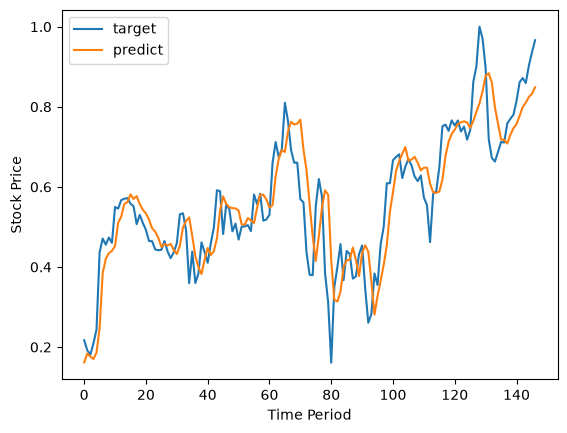

In [17]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

plt.plot(testY)
plt.plot(test_predict)
plt.xlabel('Time Period')
plt.ylabel('Stock Price')
plt.legend(['target', 'predict']) # 정답 데이터, 예측 데이터
plt.show()